## Aim 

In this code, the Land Surface Temperature data (LST) using band 10 at the ward level are merged with the road characteristics. The analysis is only for the drivable roads

In [1]:
from pathlib import Path

## import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress, pearsonr
from sklearn.linear_model import LinearRegression

## Reading in the data

In [2]:
# Define the paths
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
IMAGES_DIR = BASE_DIR / "images"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


### Land Surface Temperature

In [3]:
lst_path = PROCESSED_DIR /'lstband10summer_chennai.csv'
print(lst_path)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\lstband10summer_chennai.csv


In [4]:
df_lst_mean_summer = pd.read_csv(lst_path)

In [5]:
df_lst_mean_summer.head()

,system:index,zone_id,mean,zone_name,Name
0,0,13,40.361148,Adyar,168
1,1,13,39.219309,Adyar,169
2,2,13,37.738077,Adyar,170
3,3,13,37.393918,Adyar,171
4,4,13,37.216989,Adyar,174


In [6]:
print(f"The minimum temperature is {df_lst_mean_summer['mean'].min()}.")
print(f"The maximum temperature is {df_lst_mean_summer['mean'].max()}.")

The minimum temperature is 37.03991818381252.
The maximum temperature is 44.48337828024445.


### Road density

In [7]:
road_density_path = PROCESSED_DIR /'results_chennai_all_roads_drive.csv'
df_road_density = pd.read_csv(road_density_path)

In [8]:
df_road_density.head()

,Unnamed: 0,Name,zone_id,zone_name,street_length,street_density,area
0,0,168,13,Adyar,54354.026881,15255.703226,3.562866e+06
1,1,169,13,Adyar,36961.811588,9809.544228,3.767944e+06
2,2,170,13,Adyar,29799.276758,11032.566178,2.701029e+06
3,3,171,13,Adyar,33712.420322,10063.696158,3.349904e+06
4,4,174,13,Adyar,38544.033039,11131.430330,3.462631e+06


In [9]:
merged = pd.merge(df_lst_mean_summer, df_road_density, on='Name')
merged.head()

,system:index,zone_id_x,mean,zone_name_x,Name,Unnamed: 0,zone_id_y,zone_name_y,street_length,street_density,area
0,0,13,40.361148,Adyar,168,0,13,Adyar,54354.026881,15255.703226,3.562866e+06
1,1,13,39.219309,Adyar,169,1,13,Adyar,36961.811588,9809.544228,3.767944e+06
2,2,13,37.738077,Adyar,170,2,13,Adyar,29799.276758,11032.566178,2.701029e+06
3,3,13,37.393918,Adyar,171,3,13,Adyar,33712.420322,10063.696158,3.349904e+06
4,4,13,37.216989,Adyar,174,4,13,Adyar,38544.033039,11131.430330,3.462631e+06


Only retain the relevant variables and rename:

In [10]:
merged = merged[['zone_id_x', 'mean', 'zone_name_x', 'Name', 'street_length', 'street_density', 'area']]
merged.head()

,zone_id_x,mean,zone_name_x,Name,street_length,street_density,area
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06


In [11]:
# Rename the columns
merged = merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name',
    'mean': 'mean_lst'
})
merged.head()

,zone_id,mean_lst,zone_name,Name,street_length,street_density,area
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06


In [12]:
print(f'The mininim street density is {merged["street_density"].min()} metres or {merged["street_density"].min()/1000} km per square km.')
print(f'The maximimum street density is {merged["street_density"].max()} metres or {merged["street_density"].max()/1000} km per square km.')

The mininim street density is 1786.0806416590865 metres or 1.7860806416590864 km per square km.
The maximimum street density is 28899.14396872097 metres or 28.89914396872097 km per square km.


In [13]:
# index of min and max street density
idx_min = merged["street_density"].idxmin()
idx_max = merged["street_density"].idxmax()

In [14]:
# ward names
ward_min = merged.loc[idx_min, "Name"]
ward_max = merged.loc[idx_max, "Name"]

In [15]:
print(f' The ward with the minimum street density is {ward_min} and the maximum street density is {ward_max}.')

 The ward with the minimum street density is 159 and the maximum street density is 41.


#### Street density

In [16]:
fig_path = IMAGES_DIR / 'regression_chennai_street_density_drive.png'

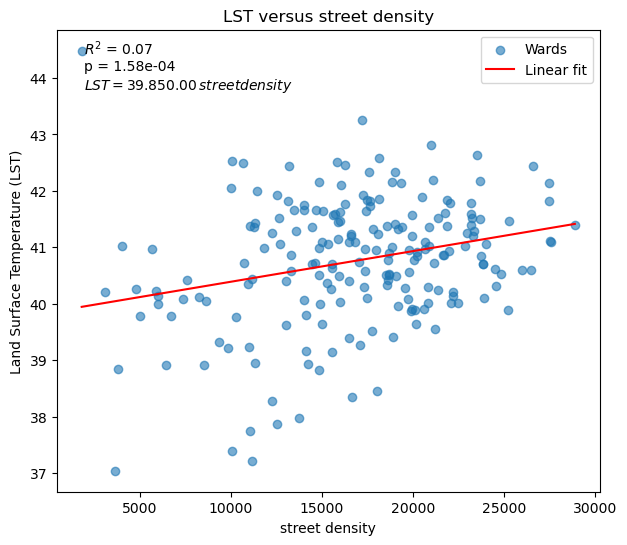

In [17]:
# x and y
x = merged["street_density"]
y = merged["mean_lst"]

# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("street density")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus street density")
plt.legend()

# annotation
plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,street density$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()


In [18]:
p_value

np.float64(0.0001580956805440855)

In [19]:
print(slope, intercept, r_value)

5.421769169436895e-05 39.84753211625238 0.26404303249227523


In [20]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.2640430324922753), pvalue=np.float64(0.000158095680544087))

In [21]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['street_density']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     14.84
Date:                Sat, 17 Jan 2026   Prob (F-statistic):           0.000158
Time:                        13:52:55   Log-Likelihood:                -300.01
No. Observations:                 200   AIC:                             604.0
Df Residuals:                     198   BIC:                             610.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             39.8475      0.249    159.

In [22]:
pearsonr(merged['street_density'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.2640430324922753), pvalue=np.float64(0.000158095680544087))

#### Straightness

In [23]:
straightness_path = PROCESSED_DIR /'results_chennai_straightness_all_roads_drive.csv'
df_straightness = pd.read_csv(straightness_path)

In [24]:
df_straightness.head()

,Unnamed: 0,Name,zone_id,zone_name,straightness
0,0,168,13,Adyar,0.681339
1,1,169,13,Adyar,0.602852
2,2,170,13,Adyar,0.687663
3,3,171,13,Adyar,0.699583
4,4,174,13,Adyar,0.717740


In [25]:
merged = pd.merge(merged, df_straightness, on='Name')
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,Unnamed: 0,zone_id_y,zone_name_y,straightness
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0,13,Adyar,0.681339
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,1,13,Adyar,0.602852
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,2,13,Adyar,0.687663
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,3,13,Adyar,0.699583
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,4,13,Adyar,0.717740


In [26]:
merged = merged[['zone_id_x', 'mean_lst', 'zone_name_x', 'Name','street_length', 'street_density', 'area', 'straightness']]
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0.681339
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,0.602852
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,0.687663
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,0.699583
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,0.717740


In [27]:
# x and y
x = merged["straightness"]
y = merged["mean_lst"]

In [28]:
fig_path = IMAGES_DIR / 'regression_chennai_straightness_drive.png'

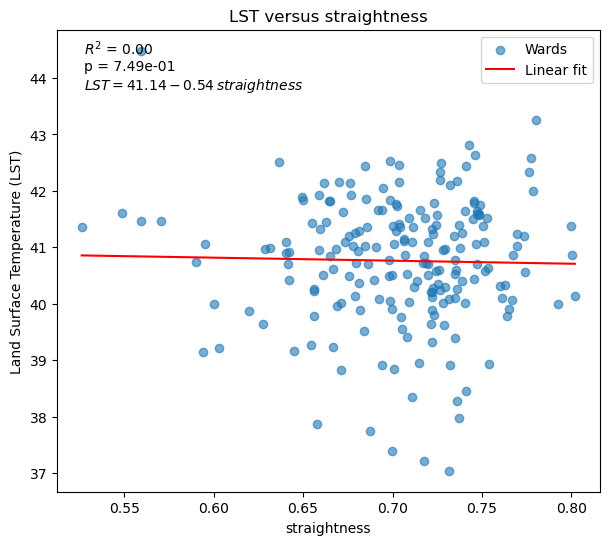

In [29]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("straightness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus straightness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST = {intercept:.2f}{slope:.2f}\\,straightness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [30]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['straightness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.1030
Date:                Sat, 17 Jan 2026   Prob (F-statistic):              0.749
Time:                        13:53:28   Log-Likelihood:                -307.18
No. Observations:                 200   AIC:                             618.4
Df Residuals:                     198   BIC:                             625.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           41.1377      1.178     34.909   

In [31]:
pearsonr(merged['straightness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(-0.02280613481412167), pvalue=np.float64(0.7485533025753625))

#### Global closeness

In [32]:
global_closeness_path = PROCESSED_DIR /'results_chennai_global_closeness_all_roads_drive.csv'
df_global_closeness = pd.read_csv(global_closeness_path)

In [33]:
df_global_closeness.head()

,Unnamed: 0,Name,zone_id,zone_name,closeness
0,0,168,13,Adyar,0.000745
1,1,169,13,Adyar,0.000576
2,2,170,13,Adyar,0.000717
3,3,171,13,Adyar,0.000804
4,4,174,13,Adyar,0.000934


In [34]:
merged = pd.merge(merged, df_global_closeness, on='Name')
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness,Unnamed: 0,zone_id,zone_name,closeness
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0.681339,0,13,Adyar,0.000745
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,0.602852,1,13,Adyar,0.000576
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,0.687663,2,13,Adyar,0.000717
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,0.699583,3,13,Adyar,0.000804
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,0.717740,4,13,Adyar,0.000934


In [35]:
merged = merged[['zone_id_x', 'mean_lst', 'zone_name_x', 'Name', 'street_length', 'street_density', 'area', 'straightness', 'closeness']]
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness,closeness
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0.681339,0.000745
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,0.602852,0.000576
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,0.687663,0.000717
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,0.699583,0.000804
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,0.717740,0.000934


In [36]:
# Rename the columns
merged = merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name',
    'closeness': 'global_closeness'
})
merged.head()

,zone_id,mean_lst,zone_name,Name,street_length,street_density,area,straightness,global_closeness
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0.681339,0.000745
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,0.602852,0.000576
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,0.687663,0.000717
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,0.699583,0.000804
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,0.717740,0.000934


In [37]:
# x and y
x = merged["global_closeness"]
y = merged["mean_lst"]

In [38]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [39]:
fig_path = IMAGES_DIR / 'regression_chennai_global_closeness_drive.png'

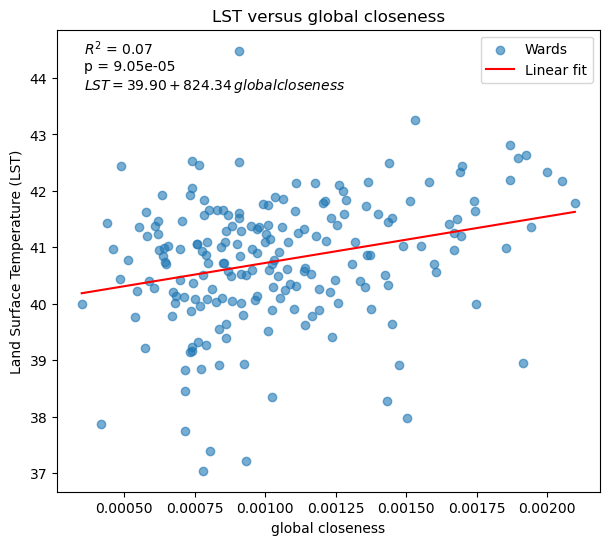

In [40]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("global closeness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus global closeness")
plt.legend()

# annotation

plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,global closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [41]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['global_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     15.98
Date:                Sat, 17 Jan 2026   Prob (F-statistic):           9.05e-05
Time:                        13:53:46   Log-Likelihood:                -299.48
No. Observations:                 200   AIC:                             603.0
Df Residuals:                     198   BIC:                             609.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               39.8974      0.229  

In [42]:
pearsonr(merged['global_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.2732390422332386), pvalue=np.float64(9.050919959421459e-05))

#### Local closeness

In [43]:
local_closeness_path = PROCESSED_DIR /'results_chennai_local_closeness_all_roads_drive.csv'
df_local_closeness = pd.read_csv(local_closeness_path)
df_local_closeness.head()

,Unnamed: 0,Name,zone_id,zone_name,closeness_local
0,0,168,13,Adyar,0.000387
1,1,169,13,Adyar,0.000424
2,2,170,13,Adyar,0.000478
3,3,171,13,Adyar,0.000480
4,4,174,13,Adyar,0.000448


In [44]:
merged = pd.merge(merged, df_local_closeness, on='Name')
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness,global_closeness,Unnamed: 0,zone_id_y,zone_name_y,closeness_local
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0.681339,0.000745,0,13,Adyar,0.000387
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,0.602852,0.000576,1,13,Adyar,0.000424
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,0.687663,0.000717,2,13,Adyar,0.000478
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,0.699583,0.000804,3,13,Adyar,0.000480
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,0.717740,0.000934,4,13,Adyar,0.000448


In [45]:
merged = merged[['zone_id_x', 'mean_lst', 'zone_name_x','Name', 'street_length', 'street_density', 'area', 'straightness', 'global_closeness', 'closeness_local']]
merged.head()

,zone_id_x,mean_lst,zone_name_x,Name,street_length,street_density,area,straightness,global_closeness,closeness_local
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0.681339,0.000745,0.000387
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,0.602852,0.000576,0.000424
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,0.687663,0.000717,0.000478
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,0.699583,0.000804,0.000480
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,0.717740,0.000934,0.000448


In [46]:
# Rename the columns
merged = merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name',
    'closeness_local': 'local_closeness'
})
merged.head()

,zone_id,mean_lst,zone_name,Name,street_length,street_density,area,straightness,global_closeness,local_closeness
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0.681339,0.000745,0.000387
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,0.602852,0.000576,0.000424
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,0.687663,0.000717,0.000478
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,0.699583,0.000804,0.000480
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,0.717740,0.000934,0.000448


In [47]:
# x and y
x = merged["local_closeness"]
y = merged["mean_lst"]

In [48]:
# plot
# plt.figure(figsize=(7, 6))
# plt.scatter(x, y, alpha=0.6, label="Pixels")

In [49]:
fig_path = IMAGES_DIR / 'regression_chennai_local_closeness_drive.png'

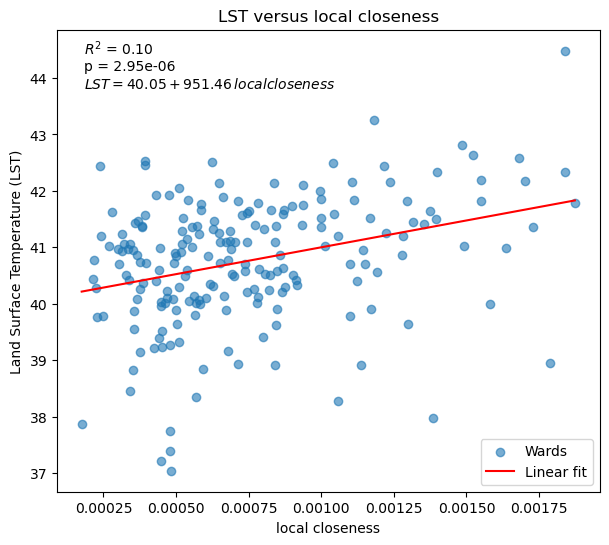

In [51]:
# linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line

# plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.6, label="Wards")
plt.plot(x_line, y_line, color="red", label="Linear fit")

plt.xlabel("local closeness")
plt.ylabel("Land Surface Temperature (LST)")
plt.title("LST versus local closeness")
plt.legend()


# annotation


plt.text(
    0.05, 0.98,
    f"$R^2$ = {r_value**2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.text(
    0.05, 0.90,
    f"$LST  = {intercept:.2f} + {slope:.2f}\\,local closeness$",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [52]:
#define response variable
y = merged['mean_lst']
#define predictor variables
x = merged['local_closeness']
#add constant to predictor variables
x = sm.add_constant(x)
#fit linear regression model
model = sm.OLS(y, x).fit()
#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mean_lst   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     23.16
Date:                Sat, 17 Jan 2026   Prob (F-statistic):           2.95e-06
Time:                        13:55:13   Log-Likelihood:                -296.17
No. Observations:                 200   AIC:                             596.3
Df Residuals:                     198   BIC:                             602.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              40.0481      0.166    2

In [53]:
pearsonr(merged['local_closeness'], merged['mean_lst'])

PearsonRResult(statistic=np.float64(0.32361283979018574), pvalue=np.float64(2.949783354223568e-06))

In [54]:
merged

,zone_id,mean_lst,zone_name,Name,street_length,street_density,area,straightness,global_closeness,local_closeness
0,13,40.361148,Adyar,168,54354.026881,15255.703226,3.562866e+06,0.681339,0.000745,0.000387
1,13,39.219309,Adyar,169,36961.811588,9809.544228,3.767944e+06,0.602852,0.000576,0.000424
2,13,37.738077,Adyar,170,29799.276758,11032.566178,2.701029e+06,0.687663,0.000717,0.000478
3,13,37.393918,Adyar,171,33712.420322,10063.696158,3.349904e+06,0.699583,0.000804,0.000480
4,13,37.216989,Adyar,174,38544.033039,11131.430330,3.462631e+06,0.717740,0.000934,0.000448
...,...,...,...,...,...,...,...,...,...,...
195,9,39.260790,Teynampet,110,35109.902885,17096.095318,2.053680e+06,0.654636,0.000792,0.000478
196,12,41.653612,Alandur,161,11041.122701,13982.470932,7.896403e+05,0.693922,0.000800,0.000828
197,12,41.648116,Alandur,160,10079.741179,15048.866273,6.698007e+05,0.740252,0.001745,0.001373
198,15,39.867612,Sholinganallur,195,49496.276574,19889.229253,2.488597e+06,0.619730,0.000737,0.000354


## Correlation

In [55]:
vars_df = merged[[
    "mean_lst",
    "street_density",
    "straightness",
    "global_closeness",
    "local_closeness"
]].dropna()

In [56]:
corr = vars_df.corr(method="pearson")

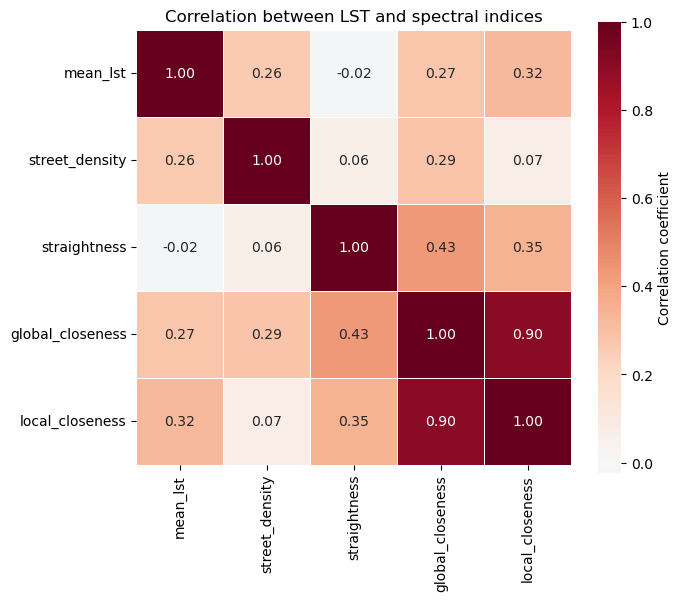

In [57]:
corr_path_indices = IMAGES_DIR / 'corr_indices_bangalore_drive.png'
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation between LST and spectral indices")
plt.tight_layout()
plt.savefig(corr_path_indices, dpi=300, bbox_inches="tight")
plt.show()